In [4]:
import pandas as pd
import numpy as np
import nibabel as nib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

(np.float64(-0.5), np.float64(255.5), np.float64(0.5), np.float64(-0.5))

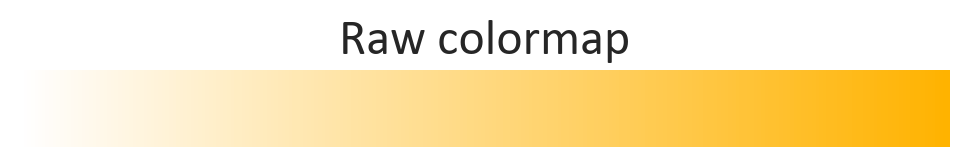

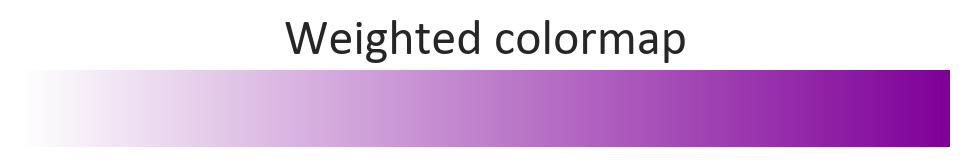

In [8]:
# ── Global visualisation configuration ──────────────────────────────────────

# 1.  General Matplotlib defaults
# ── Global visualisation configuration ──────────────────────────────────────
import matplotlib as mpl
import seaborn as sns

# Add font family to the rcParams (from tff file)
from matplotlib import font_manager

font_path = Path.home() / ".fonts/calibri-regular.ttf"
font_manager.fontManager.addfont(font_path)


mpl.rcParams.update(
    {
        # ── Canvas size & resolution ───────────────────────────────────────────
        # Default figure size: 12×8 inches  →  4800×3200 px when exported at 400 dpi
        "figure.figsize": (12, 8),
        "figure.dpi": 200,  # crisp in-notebook / retina preview
        "savefig.dpi": 400,  # print-quality PNG/PDF
        # ── Fonts ──────────────────────────────────────────────────────────────
        "font.family": "Calibri",
        # "font.sans-serif": ["Roboto", "DejaVu Sans", "Arial"],
        "font.sans-serif": ["Calibri", "DejaVu Sans", "Arial"],
        "axes.titlesize": 24,
        # "axes.titleweight": "bold",
        "axes.labelsize": 24,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 20,
        # ── Axis & spine aesthetics ────────────────────────────────────────────
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": True,
        "axes.spines.bottom": True,
        "axes.linewidth": 1,
        "axes.grid": True,
        "grid.color": "#E6E6E6",
        "grid.linewidth": 0.4,
        "grid.alpha": 0.8,
        # ── Colour cycle (colour-blind-safe) ───────────────────────────────────
        "axes.prop_cycle": mpl.cycler(color=sns.color_palette("Set2")),
        # ── Figure background ─────────────────────────────────────────────────
        "figure.facecolor": "white",
    }
)

# Seaborn theme inherits the rcParams above
sns.set_theme(context="talk", style="whitegrid", palette="Set2")


# 2.  Seaborn theme (inherits Matplotlib rcParams)
sns.set_theme(
    context="talk",  # slightly larger fonts for presentations / papers
    style="whitegrid",  # grid only on y-axis (good for histograms)
    palette="Set2",  # matches the rcParams colour cycle
)


# 3.  Helper function for consistent figure export
def savefig_nice(fig, filename, *, tight=True, dpi=300, **savefig_kwargs):
    """Save figure with tight layout and correct DPI."""
    if tight:
        fig.tight_layout()
    fig.savefig(filename, dpi=dpi, bbox_inches="tight", transparent=True, **savefig_kwargs)


mpl.rcParams["font.family"] = "Calibri"  # or any other font you want

# 4.  Colour constants for this project (optional convenience)
# COL_RAW = "#1f77b4"  # e.g. unweighted sample
COL_RAW = "#ffb300"
# COL_WEIGHTED = "#d62728"  # weighted sample
COL_WEIGHTED = "#7F0099CE"  # weighted sample
COL_REF = "0.25"  # census reference (neutral grey)
COL_CENSUS = "#A5A5A5"

# generate colormaps from white to colour
COL_WHITE = "white"
COL_RAW_RGB = mpl.colors.to_rgb(COL_RAW)
COL_WEIGHTED_RGB = mpl.colors.to_rgb(COL_WEIGHTED)
CMAP_RAW = mpl.colors.LinearSegmentedColormap.from_list("raw", [COL_WHITE, COL_RAW_RGB], N=256)
CMAP_WEIGHTED = mpl.colors.LinearSegmentedColormap.from_list(
    "weighted", [COL_WHITE, COL_WEIGHTED_RGB], N=256
)
# visualize the colormaps
# if __name__ == "__main__":
fig, ax = plt.subplots(figsize=(6, 0.5))
ax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=CMAP_RAW)
ax.set_title("Raw colormap")
ax.axis("off")
# savefig_nice(fig, "colormap_raw.png")

fig, ax = plt.subplots(figsize=(6, 0.5))
ax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=CMAP_WEIGHTED)
ax.set_title("Weighted colormap")
ax.axis("off")
# savefig_nice(fig, "colormap_weighted.png")

In [9]:
ATLAS = "schaefer2018tian2020_400_7"
region_col = "index"
# Load important files
DATA_DIR = Path("/home/galkepler/Projects/neuroaging/data")

# Output directory for figures
OUTPUT_DIR = Path("/home/galkepler/Projects/neuroaging/figures/fig4")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load the data
parcels = pd.read_csv(DATA_DIR / "external" / "atlases" / ATLAS / "parcels.csv", index_col=0)
nifti = DATA_DIR / "external" / "atlases" / ATLAS / "atlas.nii.gz"
nifti_matlab = DATA_DIR / "external" / "atlases" / ATLAS / "atlas_matlab.nii"

In [10]:
predictions_df = pd.read_csv("BAG_data.csv", index_col=0)
# predictions_df = predictions_df.filter(regex="BAG")

In [11]:
israel_population = pd.read_csv(DATA_DIR / "processed" / "israel_population.csv")

In [12]:
import numpy as np
import pandas as pd


# ─────────────────────────────────────────────────────────────────────────────
def compute_poststrat_weights(
    sample_df: pd.DataFrame,
    pop_df: pd.DataFrame,
    *,
    age_col: str = "age_at_scan",
    start_col: str = "range_start",
    end_col: str = "range_end",
    pop_total_col: str = "total",
    cap: float | None = None,
    return_bin_table: bool = False,
):
    """
    Post-stratification weights so that the age distribution of *sample_df*
    matches an external population distribution supplied in *pop_df*.

    Parameters
    ----------
    sample_df : DataFrame with an ``age_col`` column (years; int or float).
    pop_df    : DataFrame with columns
                    [start_col, end_col, pop_total_col].
                * Values in ``pop_total_col`` can be counts **or** percentages
                  (they are internally re-scaled to proportions).
                * The row order doesn’t matter; they will be sorted.
    cap       : Optional float.  If provided, weights are truncated at
                ``cap × mean(weight)`` and then re-scaled so mean(weight)=1.
    return_bin_table : If True, also return a DataFrame summarising
                       n_sample, n_pop, and weight_factor for every bin.

    Returns
    -------
    weights   : 1-D numpy array aligned with ``sample_df.index``.
    bin_table : (optional) tidy per-bin summary (see above).
    """

    # 1 ── tidy & validate the population table --------------------------------
    pop = (
        pop_df[[start_col, end_col, pop_total_col]]
        .dropna()
        .astype({start_col: int, end_col: int, pop_total_col: float})
        .sort_values(start_col)  # your CSV is descending; fix that
        .reset_index(drop=True)
    )

    if (pop[end_col] <= pop[start_col]).any():
        raise ValueError("Each range_end must exceed range_start.")

    if (pop[start_col].iloc[1:].values < pop[end_col].iloc[:-1].values).any():
        overlap = pop.iloc[
            np.where(pop[start_col].iloc[1:].values < pop[end_col].iloc[:-1].values)[0] + 1
        ][[start_col, end_col]]
        raise ValueError(
            "Age bins overlap (rows shown below) — "
            "merge / correct them before weighting:\n"
            f"{overlap}"
        )

    # 2 ── build right-inclusive bin edges  (···| s_i  …  e_i | s_{i+1} …) ----
    edges = pop[start_col].tolist() + [pop[end_col].iloc[-1]]

    # 3 ── assign every participant to a bin -----------------------------------
    s_bins = pd.cut(
        sample_df[age_col],
        bins=edges,
        right=True,
        include_lowest=True,
        labels=pop.index,  # categorical labels 0,1,…
    )

    # 4 ── compute *sample* and *population* proportions per bin --------------
    n_sample = s_bins.value_counts(sort=False).sort_index()
    prop_sample = n_sample / n_sample.sum()

    prop_pop = pop[pop_total_col] / pop[pop_total_col].sum()

    # 5 ── weight factor = pop_prop / sample_prop ------------------------------
    weight_factor = prop_pop / prop_sample.replace(0, np.nan)  # avoid /0 → NaN

    # 6 ── map factor back to each row ----------------------------------------
    w = s_bins.map(weight_factor).astype(float).to_numpy()
    w = np.where(np.isnan(w), 0.0, w)  # rows that fell outside bins → 0

    # 7 ── optional weight truncation (winsorisation) --------------------------
    if cap is not None and cap > 0:
        mean_pos = w[w > 0].mean()
        w = np.clip(w, 0, cap * mean_pos)

    # 8 ── re-scale so mean(weight > 0) == 1 -----------------------------------
    positive = w > 0
    w[positive] = w[positive] / w[positive].mean()

    # 9 ── return --------------------------------------------------------------
    if return_bin_table:
        bin_tbl = pd.DataFrame(
            {
                "n_sample": n_sample,
                "n_pop": prop_pop * n_sample.sum(),  # rescaled to sample size
                "prop_sample": prop_sample,
                "prop_pop": prop_pop,
                "weight_factor": weight_factor,
            }
        )
        return w, bin_tbl

    return w

In [13]:
df_cov = pd.read_csv("~/Projects/plasticityhub/sessions.csv")
df_cov["subject_code"] = (
    df_cov["subject_code"]
    .astype(str)
    .str.replace("-", "")
    .str.replace(" ", "")
    .str.replace("_", "")
)
# df_cov = pd.read_csv("~/Projects/neuroaging/data/external/sessions.csv")
df_cov = df_cov.drop_duplicates(subset=["subject_code"]).set_index("subject_code")
# df_cov = pd.read_pickle(f"/media/storage/phd/papers/aging/{ATLAS}/gm_vol.pkl").reset_index(
#     drop=True
# )
# df_cov = pd.read_csv("~/Projects/plasticityhub/sessions.csv")
# df_cov = pd.read_csv("qV1v.csv")

# finished_subjects = (
#     pd.read_csv("/media/storage/phd/papers/aging/schaefer2018tian2020_400_7/subjects.csv")
#     .values.flatten()
#     .tolist()
# )
# df_cov = df_cov[df_cov["Subject Code"].isin(finished_subjects)]

# df_cov = df_cov.groupby("subject_code").first()
df = df_cov.merge(predictions_df, left_on="subject_code", right_index=True, how="outer")
df = df.dropna(subset="stacked_BAG")
# merge with cov
# df_cov = df_cov.merge(cov, left_on="subject_code", right_index=True, how="inner")
df["BMI"] = df["weight"] / ((df["height"] / 100) ** 2)


# exercise_frequency_mapping = {
#     "פעמיים-שלוש בשבוע": 2.5,
#     "1-1": 1.5,
#     "יותר מ-3 פעמים בשבוע": 4,
# }
# df_cov["exercise_frequency"] = df_cov["exercise_frequency"].map(
#     exercise_frequency_mapping
# )
df.loc[df["filled"], "number_of_children"] = df.loc[df["filled"], "number_of_children"].fillna(0)

education_level_mapping = {
    "elementary school": 1,
    "partial high school": 2,
    "high_school": 3,
    "post-secondary": 4,
    "undergraduate": 5,
    "bachelor's degree": 6,
    "U": np.nan,
    # "other": np.nan,
}
df["education_level"] = df["education_level"].map(education_level_mapping)

for col in ["blood_sugar", "blood_pressure", "thyroids", "lipids"]:
    df[col] = (
        df[col]
        .str.lower()
        .map(
            {
                "high": 1,
                "normal": 0,
                "low": -1,
                "very low": -2,
                "very high": 2,
            }
        )
    )

In [14]:
df["postrat_weight"], _ = compute_poststrat_weights(
    df,
    israel_population,
    age_col="age_at_scan",
    cap=None,  # try None first; if still spiky, use 4 or 5
    return_bin_table=True,
)

In [15]:
from sklearn.preprocessing import MultiLabelBinarizer

a = (
    df["nutrition"]
    .str.replace("קטוגני/נמנע מפחמימות", "Ketogenic")
    .str.replace("Free from", "Ketogenic")
    .str.replace(",", " ")
    .str.strip()
    .fillna("Unknown")
)


ml = MultiLabelBinarizer()
nutrition_df = pd.DataFrame(ml.fit_transform(a.str.split()), columns=ml.classes_, index=a.index)
nutrition_df = nutrition_df.rename(columns=lambda x: x.replace(" ", "_").replace("-", "_"))
nutrition_df = nutrition_df.add_prefix("nutrition_")
df = df.join(nutrition_df).drop(columns=["nutrition"])

In [16]:
fs_output_template = (
    "/media/storage/yalab-dev/derivatives/freesurfer/sub-{subj}/stats/aseg_stats.csv"
)
for subject in df.index:
    fs_output = fs_output_template.format(subj=subject)
    if not Path(fs_output).exists():
        print(f"File {fs_output} does not exist, skipping subject {subject}")
        continue
    fs_df = pd.read_csv(fs_output, sep="\t")
    for col in fs_df.columns:
        df.loc[
            subject,
            col.lower()
            .replace("-", "_")
            .replace("3rd", "third")
            .replace("4th", "fourth")
            .replace("5th", "fifth"),
        ] = fs_df.loc[0, col]

In [17]:
df = df.replace("", pd.NA)  # Handle empty missing

In [18]:
# df.filter(regex="ventricle")
df["lateral_ventricles_mean"] = df.filter(regex="lateral_ventricle").mean(axis=1)
# df

In [19]:
fill_to_0 = [
    "weekly_workouts",
    "home_cooking_times_per_week",
    "number_of_children",
    "relationship_duration",
    # "smoking",
    # "cannabis",
]
for col in fill_to_0:
    df.loc[df["filled"], col] = df.loc[df["filled"], col].fillna(0)

In [20]:
mask = df["smoking"] == False & df["smoke_frequency_per_day"].isna()
df.loc[mask, "smoke_frequency_per_day"] = 0

mask = df["cannabis"] == False & df["canabis_frequency_per_week"].isna()
df.loc[mask, "canabis_frequency_per_week"] = 0

# df.loc[df["psychometric_score"] == 200, "psychometric_score"] = np.nan

In [21]:
import pandas as pd
from scipy.stats import spearmanr, ttest_ind, f_oneway, pointbiserialr

# import statsmodels.api as OLS
from statsmodels.tools.tools import add_constant

features = [
    "psqi",
    "gad7",
    "phq9",
    "swls",
    "pcl5",
    "b5_extraversion",
    "b5_agreeableness",
    "b5_conscientiousness",
    "b5_emotional_stability",
    "b5_openness",
    "brain_health",
    "BMI",
    "weekly_workouts",
    "screen_time",
    "smartphone_usage",
    "home_cooking_times_per_week",
    "has_pet",
    "smoking",
    "cannabis",
    "alcohol",
    "caffeine",
    # "sugar_beverages",
    "water",
    # "nutrition",
    "marital_status",
    "number_of_children",
    "relationship_duration",
    "living_environment",
    "education_level",
    "psychometric_score",
    "lateral_ventricles_mean",
] + list(nutrition_df.columns)

target = "stacked_BAG"

In [22]:
missing_df = df[features + [target]].isna().mean().sort_values(ascending=False)
missing_df[missing_df > 0.2].head(20)
# features = [f for f in features if f not in missing_df[missing_df > 0.2].index]

swls                      0.885747
pcl5                      0.759101
phq9                      0.750194
gad7                      0.750194
psychometric_score        0.647560
education_level           0.635167
brain_health              0.484508
smoking                   0.480635
cannabis                  0.480635
screen_time               0.479473
smartphone_usage          0.479086
has_pet                   0.478311
living_environment        0.475988
water                     0.473664
psqi                      0.473664
b5_extraversion           0.473277
b5_conscientiousness      0.473277
b5_agreeableness          0.473277
alcohol                   0.473277
b5_emotional_stability    0.473277
dtype: float64

In [23]:
# Impute missing
# for col in features:
#     if df[col].dtype == "object":
#         df[col] = df[col].fillna(df[col].mode()[0])
#     else:
#         df[col] = df[col].fillna(df[col].mean())

# Convert binary to 0/1
binary_features = ["has_pet", "smoking", "cannabis"]  # Adjust based on your data
for col in binary_features:
    df[col] = df[col].map({True: 1, False: 0, "True": 1, "False": 0})  # Adjust mapping
    # df[col] = df[col].fillna(df[col].mode()[0])  # Fill NaNs with mode

# Individual effects
results = []
for f in features:
    n_missing = df[f].isna().sum()
    feat_df = df.dropna(subset=[f, target]).copy()
    # print(feat_df[f].dtype, len(feat_df[f].unique()))
    if feat_df[f].dtype == "object" or len(feat_df[f].unique()) < 5:  # Categorical or binary
        if len(feat_df[f].unique()) == 2:  # Binary
            group0 = feat_df[feat_df[f] == feat_df[f].unique()[0]][target]
            group1 = feat_df[feat_df[f] == feat_df[f].unique()[1]][target]
            t, p = ttest_ind(group0, group1)
            d = (group1.mean() - group0.mean()) / group0.std() if group0.std() != 0 else 0
            results.append((f, "binary", d, p, n_missing))
        else:  # Categorical
            groups = [feat_df[feat_df[f] == cat][target] for cat in feat_df[f].unique()]
            f_val, p = f_oneway(*groups)
            eta2 = f_val * (len(groups) - 1) / (len(df) - len(groups) + f_val * (len(groups) - 1))
            results.append((f, "categorical", eta2, p, n_missing))
    else:  # Continuous/ordinal
        r, p = spearmanr(feat_df[f], feat_df[target])
        results.append((f, "continuous", r, p, n_missing))

In [24]:
pd.DataFrame(
    results, columns=["Feature", "Type", "Effect Size", "p-value", "Missing Values"]
).sort_values("p-value")

,Feature,Type,Effect Size,p-value,Missing Values
28,lateral_ventricles_mean,continuous,0.177661,9.403540e-20,0
20,caffeine,continuous,0.099036,2.542930e-04,1222
18,cannabis,binary,-0.199162,6.906642e-03,1241
23,number_of_children,continuous,-0.067418,8.710649e-03,1069
22,marital_status,categorical,0.007095,1.063992e-02,1069
24,relationship_duration,continuous,-0.064280,1.238956e-02,1069
13,screen_time,continuous,0.053744,4.885318e-02,1238
17,smoking,binary,-0.153031,6.731887e-02,1241
31,nutrition_Other,binary,-1.030882,7.461684e-02,0
10,brain_health,continuous,0.048353,7.782600e-02,1251


In [40]:
features_vis = {
    "BMI": "(B) BMI",
    "lateral_ventricles_mean": "(A) Lat. Vent. Volume",
    "caffeine": "Caffeine Intake",
    "alcohol": "(C) Alcohol Intake",
    "psqi": "(C) PSQI Score",
    "relationship_duration": "Relationship Duration",
    "number_of_children": "Number of Children",
    "water": "Water Intake",
}

units = {
    "BMI": "kg/m²",
    "lateral_ventricles_mean": "mm³",
    "caffeine": "cups/day",
    "alcohol": "glasses/week",
    "relationship_duration": "years",
    "water": "cups/day",
    # "psqi": "PSQI Score",
}

ylims = {
    "BMI": (-0.4, 0.4),
    "lateral_ventricles_mean": (-9, 9),
    # "caffeine": "cups/day",
    "alcohol": (-1.5, 1.5),
    # "relationship_duration": "years",
    # "water": "cups/day",
    # "psqi": "PSQI Score",
}

In [26]:
from statsmodels.formula.api import ols, wls
import statsmodels.api as sm

# plot (x axis is feature, y axis is target, size is age, color is sex)
features_of_interest = ["lateral_ventricles_mean", "BMI", "caffeine", "alcohol", "psqi"]


# split age to sliding windows


def rolling_window_analysis(df, x_col="BMI", target=target, group_size=50, step=10):
    """
    Perform rolling window analysis on sorted age data.

    Sorts df by age ascending, then slides overlapping windows of size group_size with step.
    For each window, fits OLS: target ~ age_at_scan + x_col, extracts beta/p for x_col.
    Returns DF with results and fits beta ~ median_age.

    Parameters:
    - df: DataFrame with 'age', 'age_at_scan', target, x_col.
    - x_col: Predictor column (e.g., 'BMI').
    - target: Dependent variable (e.g., 'residuals').
    - group_size: Window size (default 50).
    - step: Step for overlapping windows (default 10; smaller = more overlap).

    Returns:
    - bins_df: DataFrame with per-window stats.
    - model_summary: Summary of beta ~ median_age OLS.
    """
    # Filter NaN in x_col and sort by age ascending
    df_test = df[df[x_col].notna()].copy()
    df_test = df_test.sort_values("age_at_scan", ascending=True).reset_index(drop=True)

    # Initialize results DF
    bins_df = pd.DataFrame(
        columns=[
            "median_age",
            "group_size",
            "min_age",
            "max_age",
            f"{target}_median",
            f"{x_col}_beta",
            f"{x_col}_p",
            "r2",
            "r2_adj",
            "p",
        ]
    )

    # Rolling windows loop
    for i in range(0, len(df_test) - group_size + 1, step):
        group = df_test.iloc[i : i + group_size]
        age = group["age_at_scan"].median()

        row_idx = len(bins_df)
        bins_df.loc[row_idx, "median_age"] = age
        bins_df.loc[row_idx, "group_size"] = len(group)
        bins_df.loc[row_idx, "min_age"] = group["age_at_scan"].min()
        bins_df.loc[row_idx, "max_age"] = group["age_at_scan"].max()
        bins_df.loc[row_idx, f"{target}_median"] = group[target].median()

        # OLS: target ~ age_at_scan + x_col
        formula = f"{target} ~ age_at_scan + {x_col}"
        # if fit_quadratic:
        #     formula += " + I(age_at_scan ** 2)"
        # formula = f"{target} ~ {x_col}"
        res = wls(formula, data=group, weights=group["postrat_weight"]).fit()
        bins_df.loc[row_idx, f"{x_col}_beta"] = res.params[x_col]
        bins_df.loc[row_idx, f"{x_col}_p"] = res.pvalues[x_col]
        bins_df.loc[row_idx, "r2"] = res.rsquared
        bins_df.loc[row_idx, "r2_adj"] = res.rsquared_adj
        bins_df.loc[row_idx, "p"] = res.f_pvalue  # p-value of the overall model

    bins_df["postrat_weight"], _ = compute_poststrat_weights(
        bins_df,
        israel_population,
        age_col="median_age",
        cap=None,
        return_bin_table=True,
    )
    # Correlation between beta and median_age
    formula_lin = f"{x_col}_beta ~ median_age"
    formula_quad = formula_lin + " + I(median_age ** 2)"
    model_lin = wls(
        formula_lin, data=bins_df.astype(float), weights=bins_df["postrat_weight"]
    ).fit()
    model_quad = wls(
        formula_quad, data=bins_df.astype(float), weights=bins_df["postrat_weight"]
    ).fit()

    return bins_df.astype(float), model_lin, model_quad


# fit_quadratic = False
# bins_df, model = rolling_window_analysis(df, x_col=feature, target=target, fit_quadratic=False)

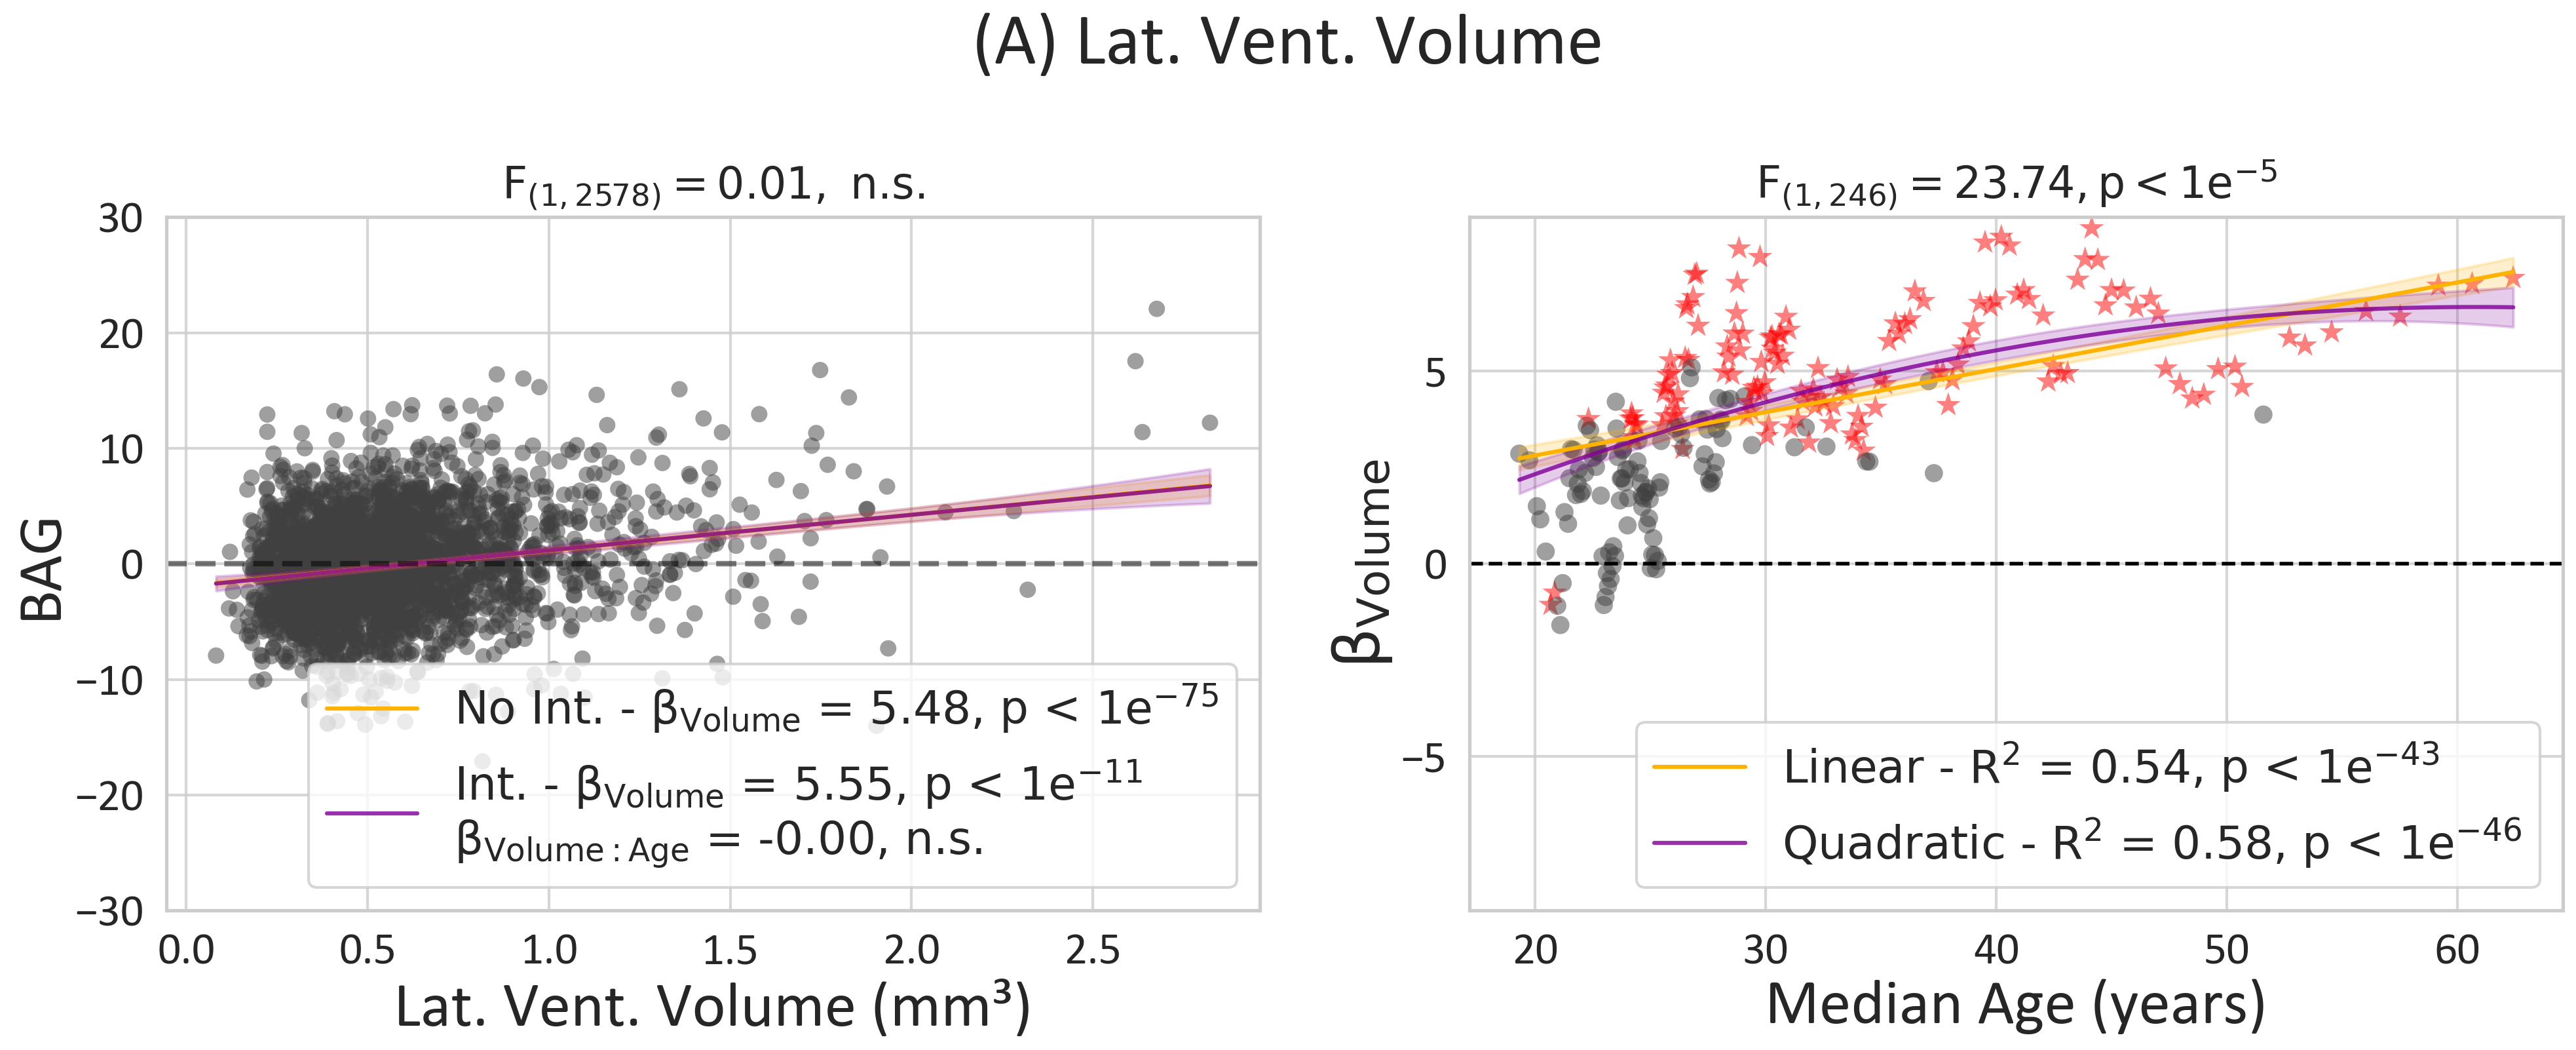

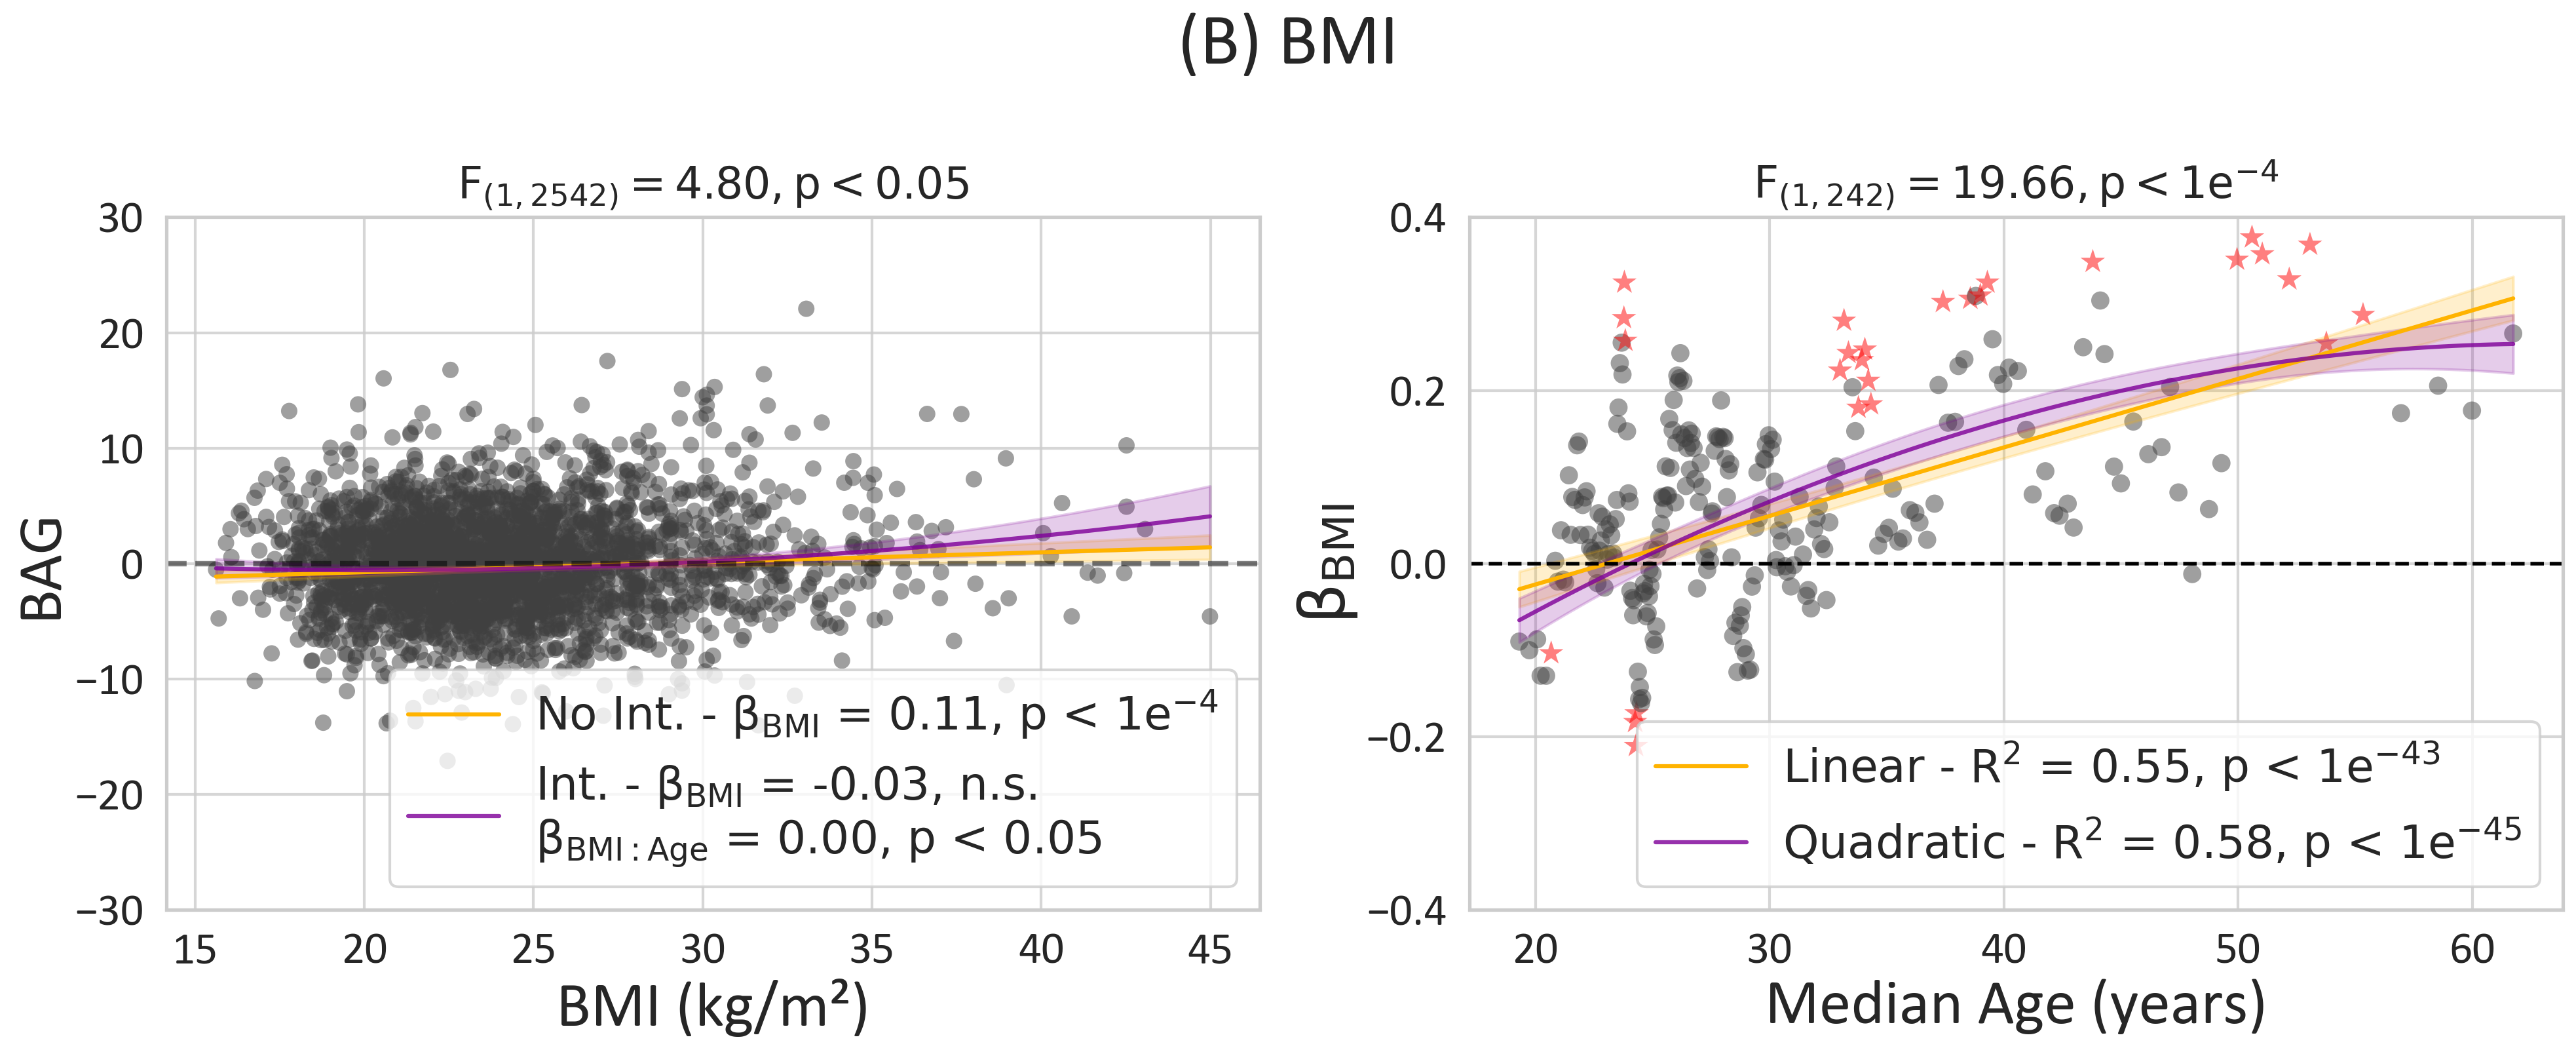

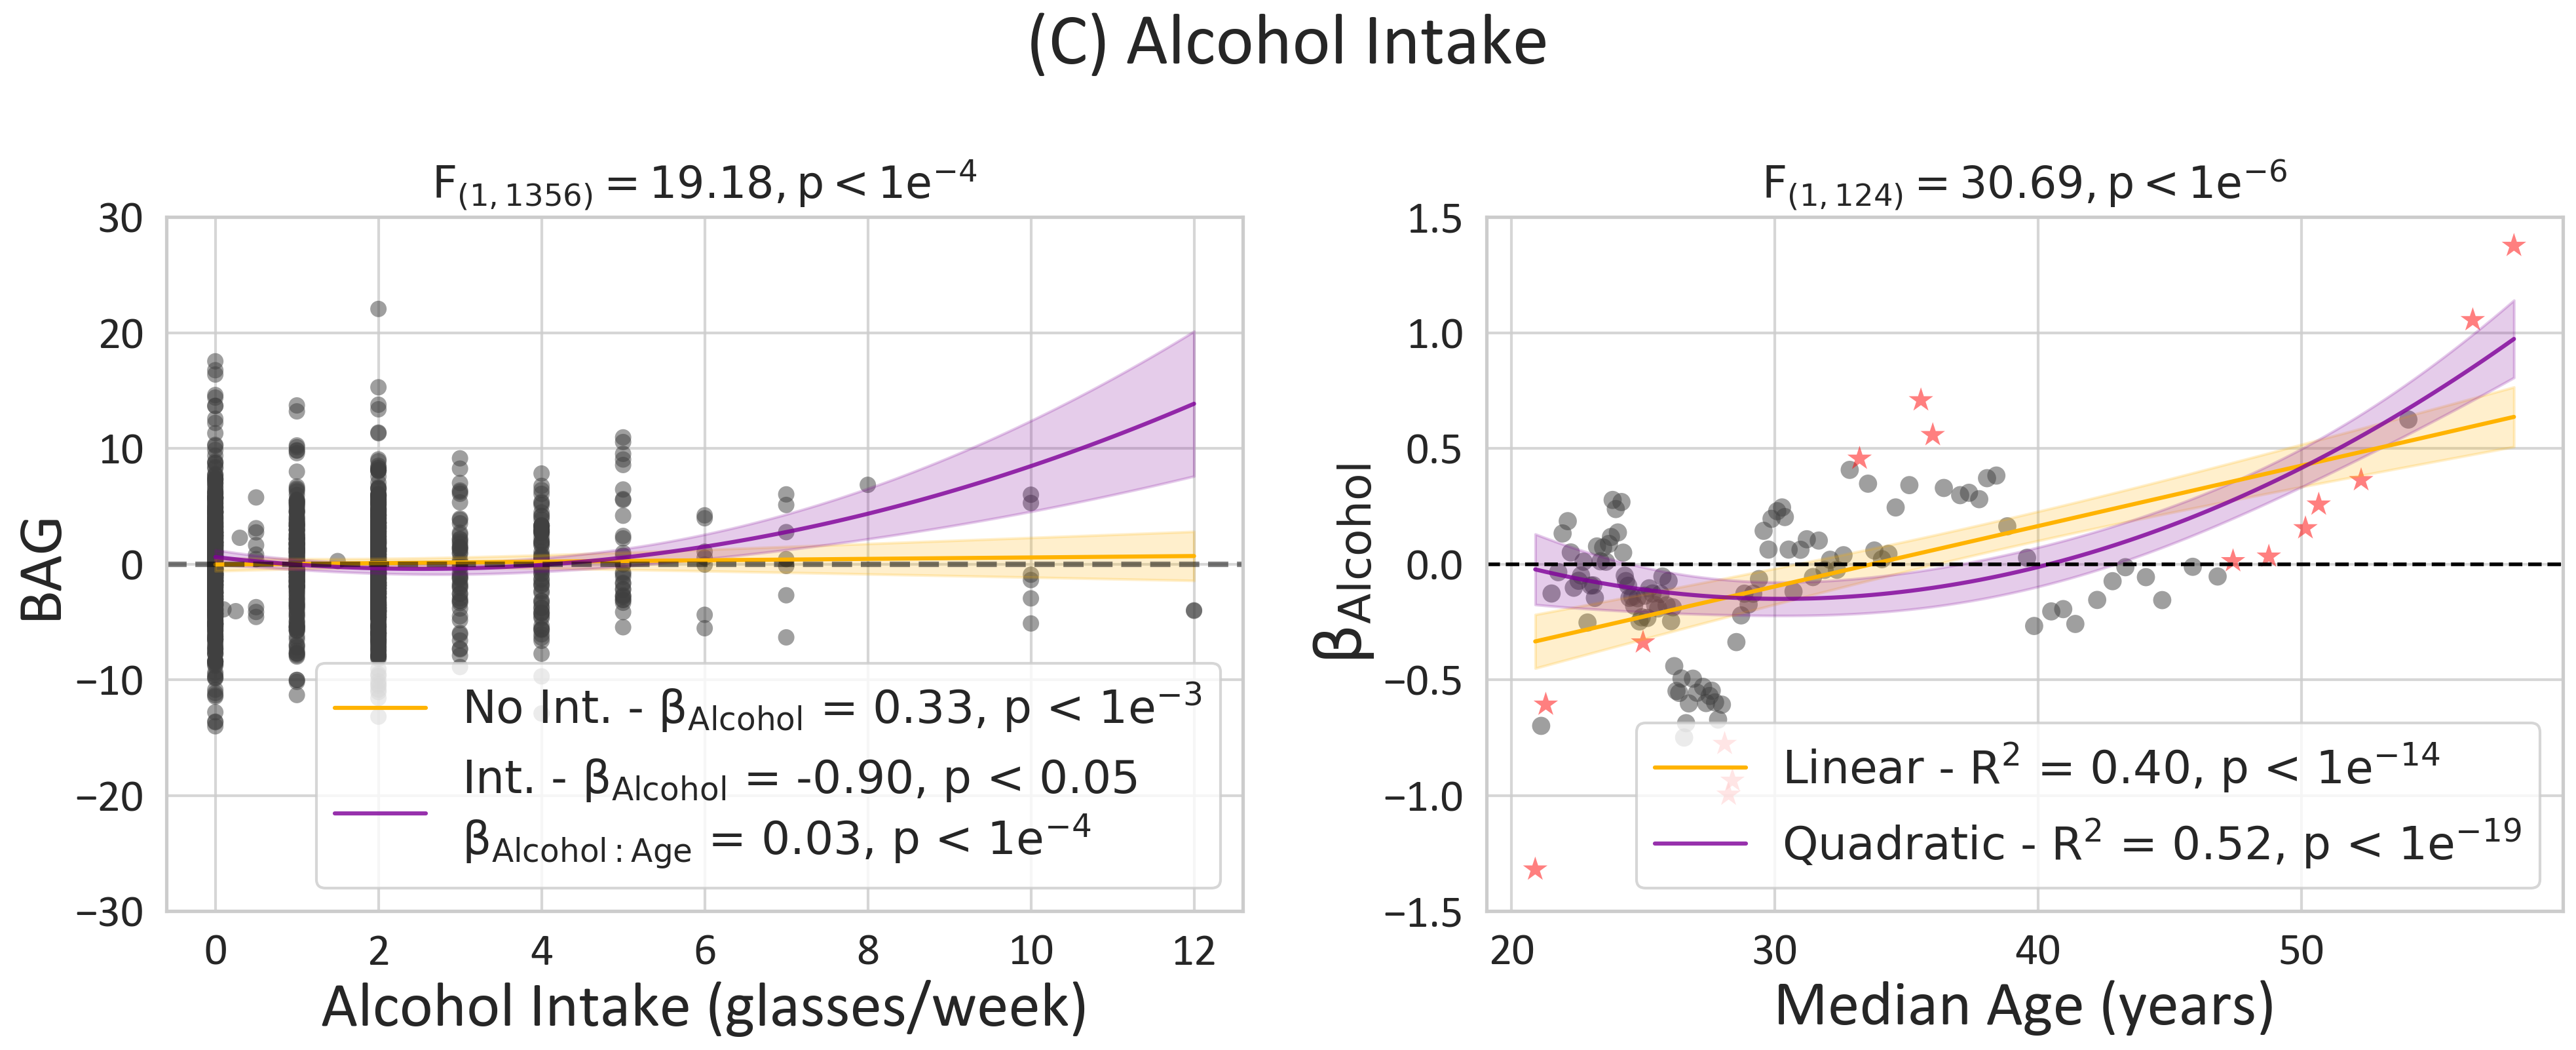

In [44]:
from statsmodels.formula.api import ols


group_size = 100
step = 10

# plot (x axis is feature, y axis is target, size is age, color is sex)

features_of_interest = ["lateral_ventricles_mean", "BMI", "alcohol"]
for feature in features_of_interest:

    mpl.rcParams.update({"axes.labelsize": 35, "ytick.labelsize": 25, "xtick.labelsize": 25, "font.family": "Calibri"})

    feature_no_lead = features_vis.get(feature, feature)
    feature_no_lead = (
        " ".join(feature_no_lead.split(" ")[1:])
        if feature_no_lead.startswith("(")
        else feature_no_lead
    )

    # Fit a linear model with OLS (include interactions)
    # for feature in features_of_interest:
    formula_int = f"{target} ~ {feature} * age_at_scan"
    formula_raw = f"{target} ~ {feature} + age_at_scan"
    model_int = wls(formula_int, data=df, weights=df["postrat_weight"])
    model_raw = wls(formula_raw, data=df, weights=df["postrat_weight"])
    results_int = model_int.fit()
    results_raw = model_raw.fit()

    f, p, df_diff = results_int.compare_f_test(results_raw)

    # get the power of p
    p_exponent = np.ceil(np.log10(p))
    # p_smaller_than = f"p < $1e^$"

    title = features_vis.get(feature, feature)
    if p < 1e-3:
        subtitle = f"$F_{{({int(df_diff)}, {int(results_int.df_resid)})}}= {f:.2f}, p < 1e^{{{int(p_exponent)}}}$"
    elif p < 0.05:
        subtitle = f"$F_{{({int(df_diff)}, {int(results_int.df_resid)})}}= {f:.2f}, p < 0.05$"
    else:
        subtitle = f"$F_{{({int(df_diff)}, {int(results_int.df_resid)})}}= {f:.2f},$ n.s."

    # print(results.summary())
    # break
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    ax = axes[0]
    sns.scatterplot(
        data=df,
        # x="age_at_scan",
        y=target,
        x=feature,
        # hue="sex",
        ax=ax,
        # palette={"M": COL_WEIGHTED, "F": COL_RAW},
        color=COL_REF,
        alpha=0.5,
        edgecolor="none",
        legend=False,
    )
    # add regression line
    # simulate data for predictions
    lines = []
    labels = []
    for lab, results in zip(
        [
            "No Int.",
            "Int.",
        ],
        [results_raw, results_int],
    ):
        pred_df = pd.DataFrame(
            {
                "age_at_scan": np.linspace(df["age_at_scan"].min(), df["age_at_scan"].max(), 100),
                feature: np.linspace(df[feature].min(), df[feature].max(), 100),
            }
        )
        predictions = results.get_prediction(pred_df)
        predictions = predictions.summary_frame(alpha=0.05)
        # plot the regression line
        lines += ax.plot(
            pred_df[feature], predictions["mean"], color=COL_WEIGHTED if lab == "Int." else COL_RAW
        )
        # labels.append(s)
        # label = f"$R^2$ = {results.rsquared:.2f}"
        label = ""
        for feat in results.params.index:
            if feat in ["Intercept", "age_at_scan"]:
                continue
            if feature in feat:
                feat_vis = (
                    feat.replace(feature, feature_no_lead)
                    .replace("Lat. Vent. ", "")
                    .replace("Score", "")
                    .replace(" Intake", "")
                )
            feat_vis = feat_vis.replace("age_at_scan", "Age")
            if "Age" in feat_vis:
                label += "\n"
            label += f"$\\beta_{{{feat_vis}}}$ = {results.params[feat]:.2f}"
            pval = results.pvalues[feat]
            p_exponent = np.ceil(np.log10(pval))
            if pval < 1e-3:
                label += f", p < $1e^{{{int(p_exponent)}}}$"
            elif pval < 0.05:
                label += f", p < 0.05"
            else:
                label += f", n.s."
        labels.append(f"{lab} - {label}")
        ax.fill_between(
            pred_df[feature],
            predictions["mean_ci_lower"],
            predictions["mean_ci_upper"],
            color=COL_WEIGHTED if lab == "Int." else COL_RAW,
            alpha=0.2,
            label=f"{lab} 95% CI",
        )

    # ax.set_title(title, fontsize=40,pad=20)
    fig.suptitle(title, fontsize=40, y=1.01)
    if subtitle:
        ax.set_title(subtitle, fontsize=24, pad=10)
    ax.set_xlabel(
        feature_no_lead + f" ({units.get(feature, '')})" if feature in units else feature_no_lead
    )
    ax.set_ylabel("BAG")
    ax.legend(lines, labels, fontsize=25, loc="lower right")
    ax.set_ylim(-30, 30)
    ax.axhline(0, color="black", linestyle="--", linewidth=3, alpha=0.5)
    # # ax.legend(lines, ["Effect Size"])
    # plt.tight_layout()

    ################################################ Rolling window analysis plot#######################################
    bins_df, mod_lin, mod_quad = rolling_window_analysis(
        df, x_col=feature, target=target, group_size=group_size, step=step
    )
    # _, mod_quad = rolling_window_analysis(
    #     df, x_col=feature, target=target, fit_quadratic=True, group_size=100
    # )
    bins_df["p < 0.05"] = bins_df["p"] < 0.05
    bins_df["size"] = bins_df["p < 0.05"].map({True: 100, False: 50}).astype(float)
    f, p, df_diff = mod_quad.compare_f_test(mod_lin)

    if p < 1e-3:
        subtitle = f"$F_{{({int(df_diff)}, {int(mod_quad.df_resid)})}}= {f:.2f}, p < 1e^{{{int(np.ceil(np.log10(p)))}}}$"
    elif p < 0.05:
        subtitle = f"$F_{{({int(df_diff)}, {int(mod_quad.df_resid)})}}= {f:.2f}, p < 0.05$"
    else:
        subtitle = f"$F_{{({int(df_diff)}, {int(mod_quad.df_resid)})}}= {f:.2f},$ n.s."

    ax = axes[1]

    sns.scatterplot(
        data=bins_df,
        x="median_age",
        y=f"{feature}_beta",
        # make p<0.05 star markers
        style="p < 0.05",
        markers={True: "*", False: "o"},
        # make p<0.05 larger
        size="size",
        sizes=(100, 200),
        # make start markers red and o markers blue
        hue="p < 0.05",
        palette={True: "red", False: COL_REF},
        ax=ax,
        legend=False,
        alpha=0.5,
        edgecolor="none",
    )
    # add regression lines
    pred_df = pd.DataFrame(
        {"median_age": np.linspace(bins_df["median_age"].min(), bins_df["median_age"].max(), 100)}
    )
    lines = []
    labels = []
    for model, col, is_quadratic in zip(
        [mod_lin, mod_quad], [COL_RAW, COL_WEIGHTED], [False, True]
    ):
        # simulate data for predictions
        predictions = model.get_prediction(pred_df)
        predictions = predictions.summary_frame(alpha=0.05)
        # plot the regression line
        lines += ax.plot(pred_df["median_age"], predictions["mean"], color=col)
        ax.fill_between(
            pred_df["median_age"],
            predictions["mean_ci_lower"],
            predictions["mean_ci_upper"],
            color=col,
            alpha=0.2,
            label="95% CI",
        )
        feat = (
            feature_no_lead.replace("Lat. Vent. ", "").replace("Score", "").replace(" Intake", "")
        )
        # label = f"$\\beta_{{{feat}}}$ ~ $Age"
        # if is_quadratic:
        #     label += f" + Age^2$"
        # else:
        #     label += "$"
        label = "Quadratic - " if is_quadratic else "Linear - "

        p_exponent = np.ceil(np.log10(model.f_pvalue))
        if model.f_pvalue < 1e-3:
            p_addition = f"p < $1e^{{{int(p_exponent)}}}$"
        elif model.f_pvalue < 0.05:
            p_addition = f"p < 0.05"
        else:
            p_addition = f"n.s."

        label += f"$R^2$ = {model.rsquared:.2f}, {p_addition}"
        labels += [label]

    ax.axhline(0, color="black", linestyle="--", linewidth=2)
    ax.legend(lines, labels, fontsize=25, loc="lower right")
    ax.set_ylim(ylims.get(feature))
    ax.set_title(subtitle, fontsize=24, pad=10)
    ax.set_xlabel("Median Age (years)")
    ax.set_ylabel(f"$\\beta_{{{feat}}}$")

    savefig_nice(fig, OUTPUT_DIR / f"example1_{feature}.png", dpi=400, tight=True)
    # break

In [60]:
features_of_interest = [
    "lateral_ventricles_mean",
    "BMI",
    "caffeine",
    "alcohol",
    "psqi",
    # "relationship_duration",
    # "water",
    "smoking",
    # "screen_time"
]

df_of_interest = df[features_of_interest + [target, "postrat_weight", "age_at_scan"]]
df_of_interest["smoking"] = df_of_interest["smoking"].fillna(df_of_interest["smoking"].mode()[0])
df_of_interest = df_of_interest.fillna(df_of_interest.mean())

/tmp/ipykernel_479959/494265933.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_of_interest["smoking"] = df_of_interest["smoking"].fillna(df_of_interest["smoking"].mode()[0])


In [61]:
from sklearn.calibration import cross_val_predict
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from itertools import combinations
from tqdm import tqdm


# ranging from 1 to n(features)
n_features = len(features_of_interest)
results = pd.DataFrame(
    columns=["n_features", "feature_combination", "mse", "r2", "mae", "adj_r2", "aic"]
)

age_regressor = wls(
    "stacked_BAG ~ age_at_scan", data=df_of_interest, weights=df_of_interest["postrat_weight"]
).fit()
df_of_interest["stacked_BAG_no_age"] = age_regressor.resid

for n in tqdm(range(1, n_features + 1), desc="Feature Combinations"):
    # create all combinations of n features
    feature_combinations = combinations(features_of_interest, n)
    for combo in feature_combinations:
        # print(f"Testing combination: {combo}")
        X = df_of_interest[list(combo) + ["age_at_scan"]]
        y = df_of_interest[target]

        # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        X_const = add_constant(X)
        model = sm.WLS(y, X_const, weights=df_of_interest["postrat_weight"]).fit()
        adj_r2 = model.rsquared_adj
        aic = model.aic

        # cross - val prediction
        model = LinearRegression()
        y_pred = cross_val_predict(model, X, y, cv=10)
        mse = mean_squared_error(y, y_pred)
        r2 = r2_score(y, y_pred)
        mae = mean_absolute_error(y, y_pred)
        results.loc[len(results)] = [
            n,
            str(combo),
            mse,
            r2,
            mae,
            adj_r2,
            aic,
        ]
        # break
    # break

Feature Combinations:  17%|█▋        | 1/6 [00:00<00:00,  9.16it/s]

Feature Combinations: 100%|██████████| 6/6 [00:01<00:00,  5.08it/s]


In [62]:
from sklearn.inspection import permutation_importance


permutation_importance_df = pd.DataFrame(columns=["feature", "importance", "std", "p_value"])
model.fit(X, y, sample_weight=df_of_interest["postrat_weight"])
res = permutation_importance(
    model,
    X,
    y,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)

/home/galkepler/Projects/neuroaging/venv/bin/python: Error while finding module specification for 'joblib.externals.loky.backend.popen_loky_posix' (ModuleNotFoundError: No module named 'joblib')
/home/galkepler/Projects/neuroaging/venv/bin/python: Error while finding module specification for 'joblib.externals.loky.backend.popen_loky_posix' (ModuleNotFoundError: No module named 'joblib')
/home/galkepler/Projects/neuroaging/venv/bin/python: Error while finding module specification for 'joblib.externals.loky.backend.popen_loky_posix' (ModuleNotFoundError: No module named 'joblib')
/home/galkepler/Projects/neuroaging/venv/bin/python: Error while finding module specification for 'joblib.externals.loky.backend.popen_loky_posix' (ModuleNotFoundError: No module named 'joblib')
/home/galkepler/Projects/neuroaging/venv/bin/python: Error while finding module specification for 'joblib.externals.loky.backend.popen_loky_posix' (ModuleNotFoundError: No module named 'joblib')
/home/galkepler/Projects/

TerminatedWorkerError: A worker process managed by the executor was unexpectedly terminated. This could be caused by a segmentation fault while calling the function or by an excessive memory usage causing the Operating System to kill the worker.

The exit codes of the workers are {EXIT(1), EXIT(1), EXIT(1), EXIT(1), EXIT(1), EXIT(1), EXIT(1), EXIT(1), EXIT(1), EXIT(1), EXIT(1), EXIT(1), EXIT(1), EXIT(1), EXIT(1), EXIT(1), EXIT(1), EXIT(1), EXIT(1), EXIT(1), EXIT(1)}
Detailed tracebacks of the workers should have been printed to stderr in the executor process if faulthandler was not disabled.

In [ ]:
permutation_importance_df["feature"] = X.columns
permutation_importance_df["importance"] = res.importances_mean
permutation_importance_df["std"] = res.importances_std
permutation_importance_df.sort_values(by="importance", ascending=False)

,feature,importance,std,p_value
0,lateral_ventricles_mean,4.345281,0.328024,NaN
6,age_at_scan,2.085402,0.160601,NaN
1,BMI,0.209469,0.044107,NaN
2,caffeine,0.010023,0.003488,NaN
5,smoking,0.002030,0.008762,NaN
4,psqi,-0.017737,0.020976,NaN
3,alcohol,-0.073545,0.109767,NaN


In [ ]:
results.sort_values(by="adj_r2", ascending=False)

,n_features,feature_combination,mse,r2,mae,adj_r2,aic
44,4,"('lateral_ventricles_mean', 'BMI', 'alcohol', ...",18.218495,0.068899,3.339502,0.137558,17058.552945
59,5,"('lateral_ventricles_mean', 'BMI', 'alcohol', ...",18.229113,0.068357,3.338080,0.137314,17060.278938
56,5,"('lateral_ventricles_mean', 'BMI', 'caffeine',...",18.131198,0.073361,3.325407,0.137255,17060.455728
62,6,"('lateral_ventricles_mean', 'BMI', 'caffeine',...",18.156831,0.072051,3.327000,0.136995,17062.231211
22,3,"('lateral_ventricles_mean', 'BMI', 'alcohol')",18.202003,0.069742,3.336963,0.136957,17059.352177
...,...,...,...,...,...,...,...
17,2,"('caffeine', 'smoking')",19.504600,0.003170,3.413856,-0.000102,17438.924329
4,1,"('psqi',)",19.624507,-0.002958,3.436003,-0.000269,17438.356428
39,3,"('caffeine', 'psqi', 'smoking')",19.528108,0.001968,3.415946,-0.000287,17440.399653
5,1,"('smoking',)",19.599906,-0.001701,3.429446,-0.000556,17439.097420


<Axes: xlabel='n_features', ylabel='adj_r2'>

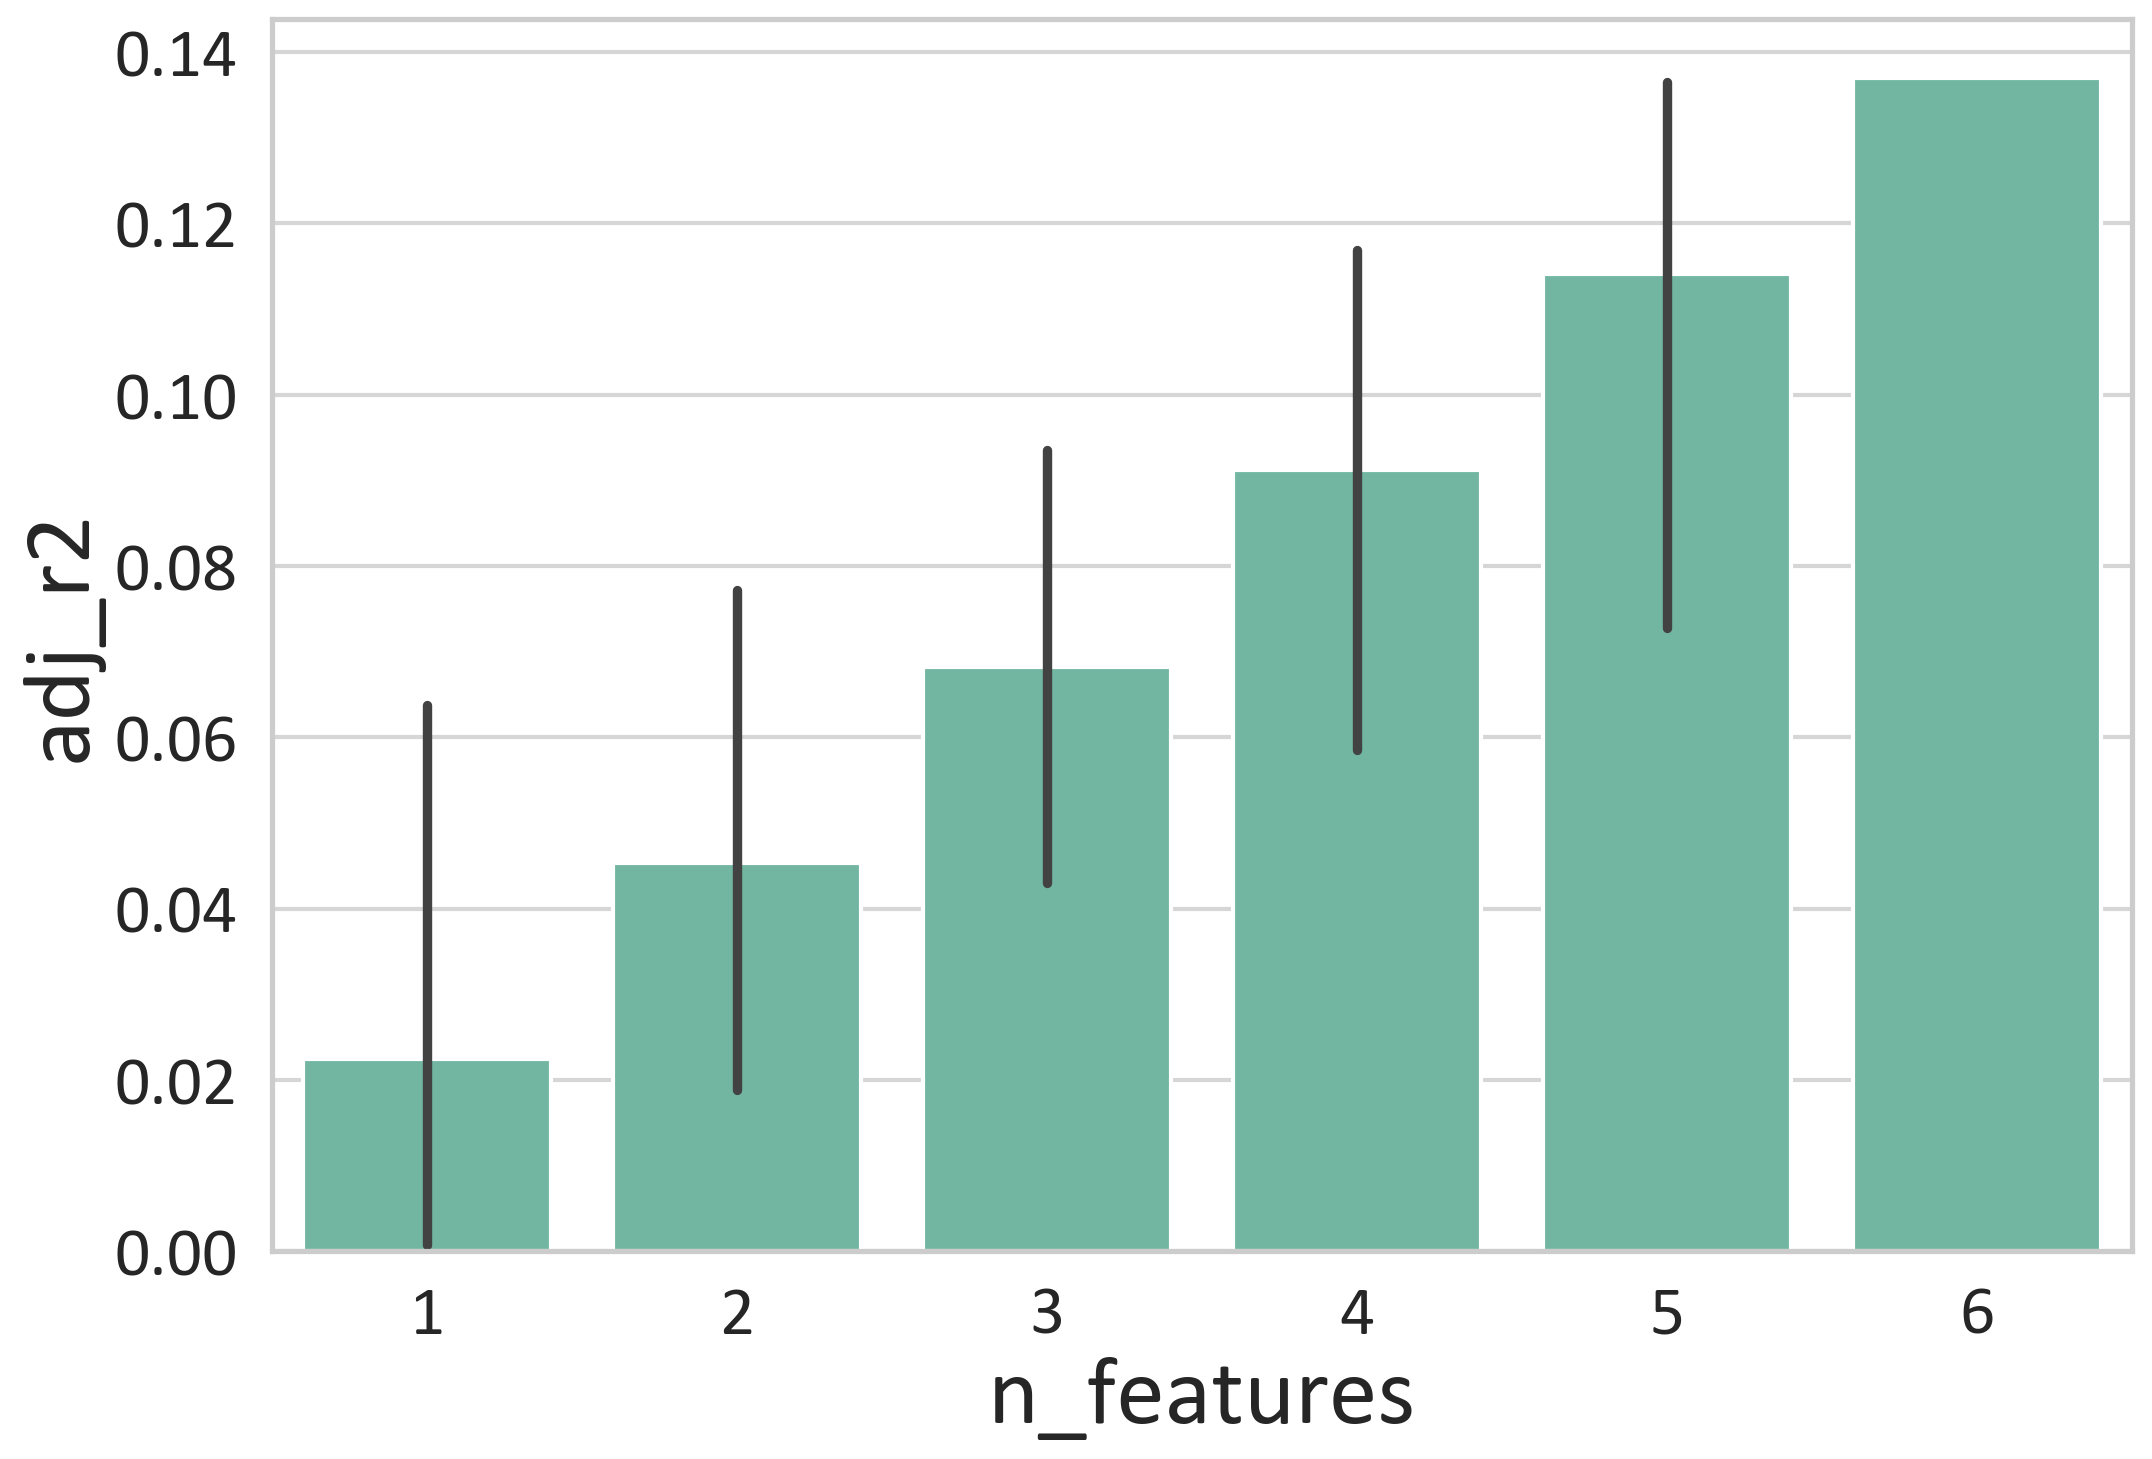

In [ ]:
sns.barplot(
    data=results,
    x="n_features",
    y="adj_r2",
    # hue="feature_combination",
    # palette="Set2",
    # ci=None,
)